In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')
from textblob import TextBlob
import os
import re
import pickle
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
import kagglehub
import os
# Download latest version
path_ecommerce = kagglehub.dataset_download("nicapotato/womens-ecommerce-clothing-reviews")

print("Path to dataset files:", path_ecommerce)


Using Colab cache for faster access to the 'womens-ecommerce-clothing-reviews' dataset.
Path to dataset files: /kaggle/input/womens-ecommerce-clothing-reviews


In [3]:
os.listdir(path_ecommerce)


['Womens Clothing E-Commerce Reviews.csv']

In [4]:
df = pd.read_csv(path_ecommerce + "/Womens Clothing E-Commerce Reviews.csv")
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [5]:
df.shape

(23486, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

,0
Unnamed: 0,0
Clothing ID,0
Age,0
Title,3810
Review Text,845
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,14
Department Name,14


In [9]:
df['Positive Feedback Count'].value_counts()

,count
Positive Feedback Count,
0,11176
1,4043
2,2193
3,1433
4,922
...,...
48,1
99,1
50,1


In [10]:
df['Department Name'].unique()

array(['Intimate', 'Dresses', 'Bottoms', 'Tops', 'Jackets', 'Trend', nan],
      dtype=object)

## the ten biggest problems that should be solved

In [11]:
negative_reviews = df[df['Rating'] <= 2]

top_urgent_complaints = negative_reviews.sort_values(by='Positive Feedback Count', ascending=False).head(10)

business_view = top_urgent_complaints[['Department Name', 'Review Text', 'Positive Feedback Count']]


display(business_view)

,Department Name,Review Text,Positive Feedback Count
7765,Jackets,"I generally don't write bad reviews, but there...",108
23427,Tops,What drew me to this shirt was the beautiful s...,65
10068,Dresses,I'm 5 feet 120 and hourglass figure. i literal...,57
657,Intimate,So i recognized the fact that this dress was l...,55
5200,Tops,I wanted to love this sweater. the color is go...,49
18506,Dresses,Do not buy this dress for full price. the desi...,48
18494,Dresses,I also returned this dress after waiting weeks...,43
12510,Tops,"There were no reviews, it's an ""online exclusi...",43
20406,Dresses,Runs small. i'm usually a size sm for retailer...,42
2793,Bottoms,So you're thinking this is a red and black ski...,42


# to know the age of womens who make the feedback


Text(0, 0.5, 'Frequency')

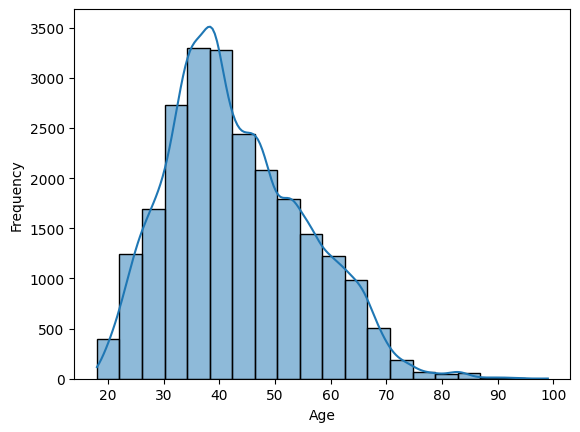

In [12]:
sns.histplot(data=df, x='Age', bins=20, kde=True)
plt.xlabel('Age')
plt.ylabel('Frequency')


In [13]:
df["Rating"].value_counts()

,count
Rating,
5,13131
4,5077
3,2871
2,1565
1,842


<Axes: xlabel='Rating', ylabel='count'>

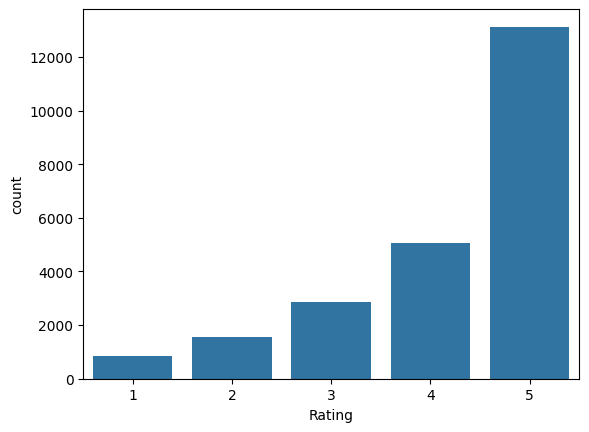

In [14]:
sns.countplot(data= df,x='Rating')

# to know if rating 3 recommed the product or not

<Axes: xlabel='Rating', ylabel='count'>

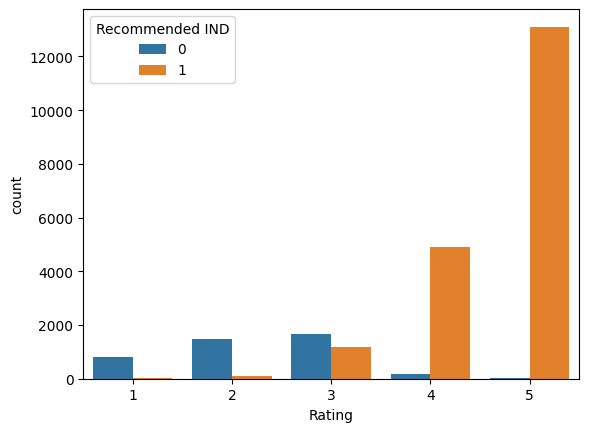

In [15]:
sns.countplot(data=df, x='Rating', hue='Recommended IND')


# to know th rating of each department To know which department is the best

<Axes: xlabel='Department Name', ylabel='count'>

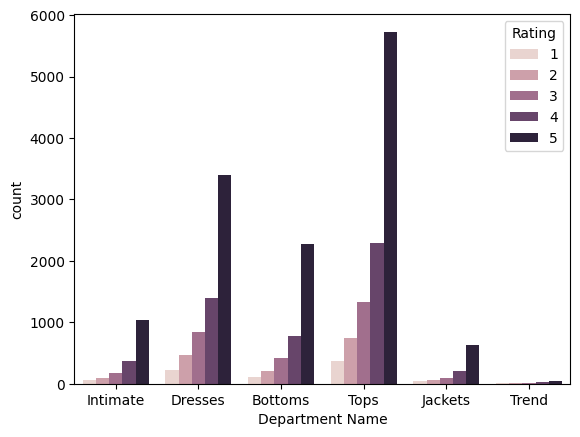

In [16]:
sns.countplot(data=df, x='Department Name',hue="Rating")


In [17]:
def categorize_age(age):
    if age < 18:
        return 'Under 18'
    elif 18 < age <= 30:
        return '18-30'
    elif 30 < age <= 40:
        return '31-40'
    elif 40 < age <= 50:
        return '41-50'
    return "over 50"
df['Categorical Age'] = df['Age'].apply(categorize_age)

# to know which range of age like to buy

<Axes: xlabel='Department Name', ylabel='count'>

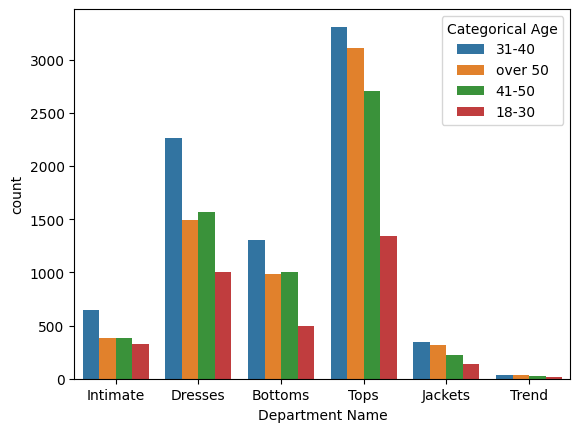

In [18]:
sns.countplot(data=df,x='Department Name',hue='Categorical Age')

In [19]:
filt = df['Rating'] == 3
df[filt]['Review Text'].to_list()
# Rating 3 is netural

['I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c',
 'Dress runs small esp where the zipper area runs. i ordered the sp which typically fits me and it was very tight! the material on the top looks and feels very cheap that even just pulling on it will cause it to rip the fabric. pretty disappointed as it was going to be my christmas dress this year! needless to say it will be going back.',
 'This is a nice choice for holiday gatherings. i like that the length grazes the knee so it is conservative enough for office related gatherings. the siz

In [20]:
filt = df['Rating'] == 4
df[filt]['Review Text'].to_list()

['Absolutely wonderful - silky and sexy and comfortable',
 "I ordered this in carbon for store pick up, and had a ton of stuff (as always) to try on and used this top to pair (skirts and pants). everything went with it. the color is really nice charcoal with shimmer, and went well with pencil skirts, flare pants, etc. my only compaint is it is a bit big, sleeves are long and it doesn't go in petite. also a bit loose for me, but no xxs... so i kept it and wil ldecide later since the light color is already sold out in hte smallest size...",
 "I took these out of the package and wanted them to fit so badly, but i could tell before i put them on that they wouldn't. these are for an hour-glass figure. i am more straight up and down. the waist was way too small for my body shape and even if i sized up, i could tell they would still be tight in the waist and too roomy in the hips - for me. that said, they are really nice. sturdy, linen-like fabric, pretty color, well made. i hope they make so

In [21]:
df = df.dropna(subset=['Review Text'])


In [22]:
df['Number Words'] = df['Review Text'].apply(lambda x: len(x.split()))


In [25]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

default_stopwords = set(stopwords.words('english'))

words_to_keep = {
    'not', 'no', 'nor', 'ain', 'aren', "aren't", 'couldn', "couldn't",
    'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn',
    "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't",
    'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn',
    "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't",
    'wouldn', "wouldn't",

    'but', 'against',
      'don', "don't",
    'ain',
    'very', 'too'
}

custom_stopwords =set( default_stopwords - words_to_keep)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [23]:

def remove_stopwords(text):
    stop_words_set = custom_stopwords
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words_set]

    return " ".join(filtered_words)

In [24]:
def remove_punctuation(text):
    PUNC = (string.punctuation).replace("'","") # to avoid making don't to dont
    translator = str.maketrans('', '', string.punctuation)
    return text.translate(translator)


In [26]:
def lemmatize(txt):
  lemmatizer = WordNetLemmatizer()
  word_list = word_tokenize(txt)
  return ' '.join([lemmatizer.lemmatize(w) for w in word_list])


In [27]:
def correct_spelling(txt):
  return str(TextBlob(txt).correct())

In [28]:
def clean_text(txt: str):
  PATTERN_TAGS = r'<.*?>'
  PATTERN_URL = r'https?://\S+|www\.\S+'
  txt = txt.strip()
  txt = txt.lower()
  txt = re.sub(PATTERN_TAGS, ' ', txt)
  txt = re.sub(r'\s{2,}', ' ', txt)
  txt = re.sub(PATTERN_URL, ' ', txt)
  txt = remove_punctuation(txt)
  txt = re.sub('\n', '', txt)
  # txt = correct_spelling(txt)
  txt = remove_stopwords(txt)
  txt = lemmatize(txt)

  return txt


In [29]:
df['Review Text'][:5].apply(clean_text)

,Review Text
0,absolutely wonderful silky sexy comfortable
1,love dress sooo pretty happened find store im ...
2,high hope dress really wanted work initially o...
3,love love love jumpsuit fun flirty fabulous ev...
4,shirt very flattering due adjustable front tie...


In [30]:
df['Cleaned Text'] = df['Review Text'].apply(clean_text)

In [31]:
def rating_encoding(row):
  POSITIVE = 1
  NEGATIVE = 0
  if row['Rating'] in (1,2):
    return NEGATIVE
  elif row['Rating'] == 3:
    if row['Recommended IND'] == 0:
      return NEGATIVE
  return POSITIVE



In [32]:
df.shape

(22641, 14)

In [33]:
df["Rating Encoded"] = df.apply(rating_encoding,axis=1)
df["Rating Encoded"].value_counts()

,count
Rating Encoded,
1,18618
0,4023


<Axes: xlabel='Rating Encoded', ylabel='count'>

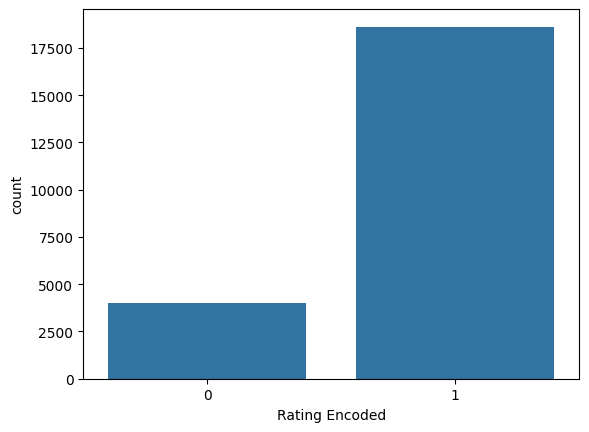

In [34]:
sns.countplot(data= df,x='Rating Encoded')

In [35]:
vectorizer = CountVectorizer()
count_words = vectorizer.fit_transform(df['Cleaned Text'])
features_names = vectorizer.get_feature_names_out()
counts_words_df = pd.DataFrame(count_words.toarray(), columns=features_names)
counts_words_df.head()

,00,000,002first,00p,00p0p,00p0rxxsxs,02,025,02xs,03,...,zipperone,zippie,zipping,zombie,zone,zoolanders,zoom,zooming,zuma,ã¼ber
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [36]:
counts_words_df['Rating'] = df['Rating Encoded'].values
counts_words_df["Rating"].value_counts()

,count
Rating,
1,18618
0,4023


In [37]:
filter_positive = counts_words_df['Rating'] == 1
filter_negative = counts_words_df['Rating'] == 0

positive_df = counts_words_df[filter_positive].drop('Rating',axis=1)
negative_df = counts_words_df[filter_negative].drop('Rating',axis=1)
top_20_positive_words = positive_df.sum().sort_values(ascending=False)[:20]
top_20_negative_words = negative_df.sum().sort_values(ascending=False)[:20]

In [38]:
top_20_negative_words

,0
but,3468
not,2472
dress,2029
like,1704
top,1632
look,1550
very,1530
fit,1423
too,1405
size,1317


In [39]:
top_20_positive_words

,0
but,12921
dress,9283
fit,8653
love,8042
size,8024
not,7395
very,6633
top,6616
color,5901
wear,5750


In [40]:
def get_top_5(row):
    top_words = row.sort_values(ascending=False).head(5)

    return ", ".join(top_words.index)


In [41]:


df['Top_5_Words'] = counts_words_df.drop('Rating', axis=1).apply(get_top_5, axis=1)

df[['Cleaned Text', 'Top_5_Words']].head()

,Cleaned Text,Top_5_Words
0,absolutely wonderful silky sexy comfortable,"absolutely, wonderful, comfortable, silky, sexy"
1,love dress sooo pretty happened find store im ...,"petite, would, love, bc, someone"
2,high hope dress really wanted work initially o...,"small, layer, net, petite, but"
3,love love love jumpsuit fun flirty fabulous ev...,"love, fun, flirty, time, nothing"
4,shirt very flattering due adjustable front tie...,"shirt, cardigan, tie, wear, perfect"


<Axes: ylabel='None'>

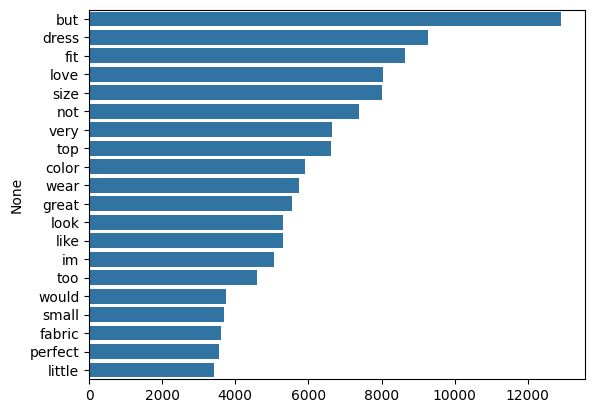

In [42]:
sns.barplot(x=top_20_positive_words.values, y=top_20_positive_words.index)

<Axes: ylabel='None'>

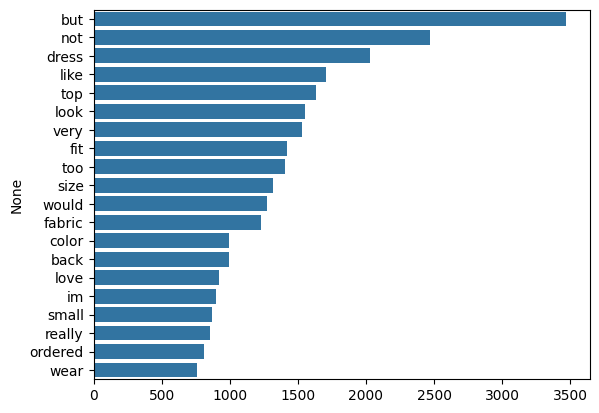

In [43]:
sns.barplot(x= top_20_negative_words.values,y=top_20_negative_words.index)

In [44]:
# 1. TF-IDF Feature Extraction
tfidf = TfidfVectorizer(max_features=2000)
X = tfidf.fit_transform(df['Cleaned Text'])
y = df['Rating Encoded']

# 2. Feature Scaling using MaxAbsScaler
scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (18112, 2000)
Test shape: (4529, 2000)


Logistic Regression Accuracy: 0.8953411349083683
Random Forest Accuracy: 0.8653124310002208


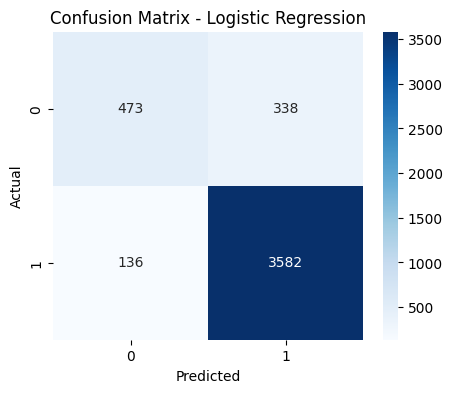

All models and transformers saved successfully!


In [45]:
# 1. Classification Model (Logistic Regression)
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)
pred1 = model1.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, pred1))

# 2. Random Forest Model
model2 = RandomForestClassifier(n_estimators=50, random_state=42)
model2.fit(X_train, y_train)
pred2 = model2.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, pred2))

# 3. Confusion Matrix Visualization
cm = confusion_matrix(y_test, pred1)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 4. K-Means Clustering for Negative Reviews
neg_df = df[df['Rating Encoded'] == 0]
X_neg = tfidf.transform(neg_df['Cleaned Text'])
X_neg_scaled = scaler.transform(X_neg)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_neg_scaled)

# 5. Save Assets using Pickle
with open('tfidf.pkl', 'wb') as f: pickle.dump(tfidf, f)
with open('scaler.pkl', 'wb') as f: pickle.dump(scaler, f)
with open('model.pkl', 'wb') as f: pickle.dump(model1, f)
with open('kmeans.pkl', 'wb') as f: pickle.dump(kmeans, f)

print("All models and transformers saved successfully!")

In [46]:
%%writefile app.py
import streamlit as st
import pickle
import re

# Page Configuration & Header
st.title("AI Customer Feedback System")
st.write("This application predicts review sentiment and categorizes complaints into clusters.")

# Load Saved Assets
with open('tfidf.pkl', 'rb') as f:
    tfidf = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('kmeans.pkl', 'rb') as f:
    kmeans = pickle.load(f)

# User Input Interface
user_review = st.text_area("Write customer review here:")

if st.button("Analyze Review"):
    if user_review.strip() != "":
        # Preprocessing
        text = user_review.lower()
        text = re.sub(r'[^a-z\s]', '', text)

        # Transformation & Scaling
        vec = tfidf.transform([text])
        vec_scaled = scaler.transform(vec)

        # Sentiment Prediction
        prediction = model.predict(vec_scaled)[0]
        prediction_proba = model.predict_proba(vec_scaled)[0]

        if prediction == 1:
            st.success(f"Result: **Positive Review** 😀 (Confidence: {prediction_proba[1]*100:.2f}%) ")
        else:
            st.error(f"Result: **Negative Review / Complaint** 🙁 (Confidence: {prediction_proba[0]*100:.2f}%) ")
            cluster = kmeans.predict(vec_scaled)[0]
            st.write(f"Complaint Group / Cluster Number: **{cluster}**")
    else:
        st.write("Please enter a review first.")

Overwriting app.py


In [47]:
import subprocess
import re

# 1. Download and setup cloudflared
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared

# 2. Start streamlit in the background and open public link
print("Launching Streamlit App...")
process = subprocess.Popen(["./cloudflared", "tunnel", "--url", "http://localhost:8501"], stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

# 3. Extract and display the live link
for line in process.stderr:
    if "trycloudflare.com" in line:
        url = re.search(r'https://[a-zA-Z0-9-]+\.trycloudflare\.com', line)
        if url:
            print("\n" + "="*55)
            print("Click the link below to open your Streamlit Web App:")
            print(url.group(0))
            print("="*55)
            break

Launching Streamlit App...

Click the link below to open your Streamlit Web App:
https://fireplace-atmosphere-member-baseball.trycloudflare.com


In [48]:
df.to_csv('cleaned_data.csv', index=False)

In [ ]:
!pkill -f streamlit

!nohup streamlit run app.py &


import urllib.request
ip = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip()
print(f"🔑 Your Tunnel Password (IP): {ip}\n")

!npx -y localtunnel --port 8501

nohup: appending output to 'nohup.out'
🔑 Your Tunnel Password (IP): 34.90.161.173

⠙⠹⠸⠼⠴your url is: https://clean-doors-act.loca.lt
